Problem Statement – Yulu Electric Cycles Demand Analysis

Yulu, India’s leading micro-mobility service provider, has recently experienced a noticeable decline in revenue. To address this issue, the company aims to understand the key factors influencing the demand for shared electric cycles in the Indian market.



**Dependent Variable**

count – Total number of electric cycles rented.

**Independent Variables**

Working day

Weather condition

Season

Temperature

humidity

windspeed

The objective of this analysis is to identify and evaluate the impact of various factors such as working day, weather conditions, seasonality, and environmental variables on the number of electric cycles rented. By performing exploratory data analysis and applying appropriate statistical hypothesis tests, we aim to determine which variables significantly affect demand and how well they explain variations in rentals.

The insights derived from this analysis will help Yulu:

Optimize fleet allocation

Improve demand forecasting

Plan operational and marketing strategies

Make data-driven business decisions

The study uses historical rental data and applies bi-variate analysis, t-tests, ANOVA, and Chi-Square tests to validate relationships between demand and influencing factors.

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [167]:
df = pd.read_csv("/content/yulu.txt")

In [168]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


What are the structure and characteristics of the dataset

In [169]:
df.dtypes

,0
datetime,object
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [170]:
df.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


There are no missing values in any column, indicating a complete and clean dataset.

No imputation or row removal is required, so the data is ready for analysis.

Ensures reliable statistical tests and modeling without bias from missing data.

In [171]:
col = df.columns
col = col[1:5]
for i in col :
  df[i] = df[i].astype("category")

In [172]:
df.dtypes

,0
datetime,object
season,category
holiday,category
workingday,category
weather,category
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [173]:
df.shape

(10886, 12)

In [174]:
df.select_dtypes(include="category").describe()

,season,holiday,workingday,weather
count,10886,10886,10886,10886
unique,4,2,2,4
top,4,0,1,1
freq,2734,10575,7412,7192


The dataset has 10,886 observations with 4 seasons, 2 holiday types, 2 working-day types, and 4 weather categories.

Non-holiday days (holiday = 0) and working days (workingday = 1) dominate the data, indicating most records are regular weekdays.

Weather category 1 and Season 4 occur most frequently, showing an imbalanced but realistic distribution across categories.

In [175]:
df.select_dtypes(include = "number").describe()

,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


Rental demand (count) is highly variable and right-skewed, with mean (191.6) greater than median (145) and a wide range (1 to 977), indicating occasional peak-demand days.

Registered users dominate rentals (mean ≈ 156 vs casual ≈ 36), showing that most demand comes from regular users rather than casual riders.

Weather-related variables (temp, atemp, humidity, windspeed) show substantial spread, suggesting they can meaningfully influence rental behavior and are important predictors.

Perform univariate analysis on continuous variables

1. Count

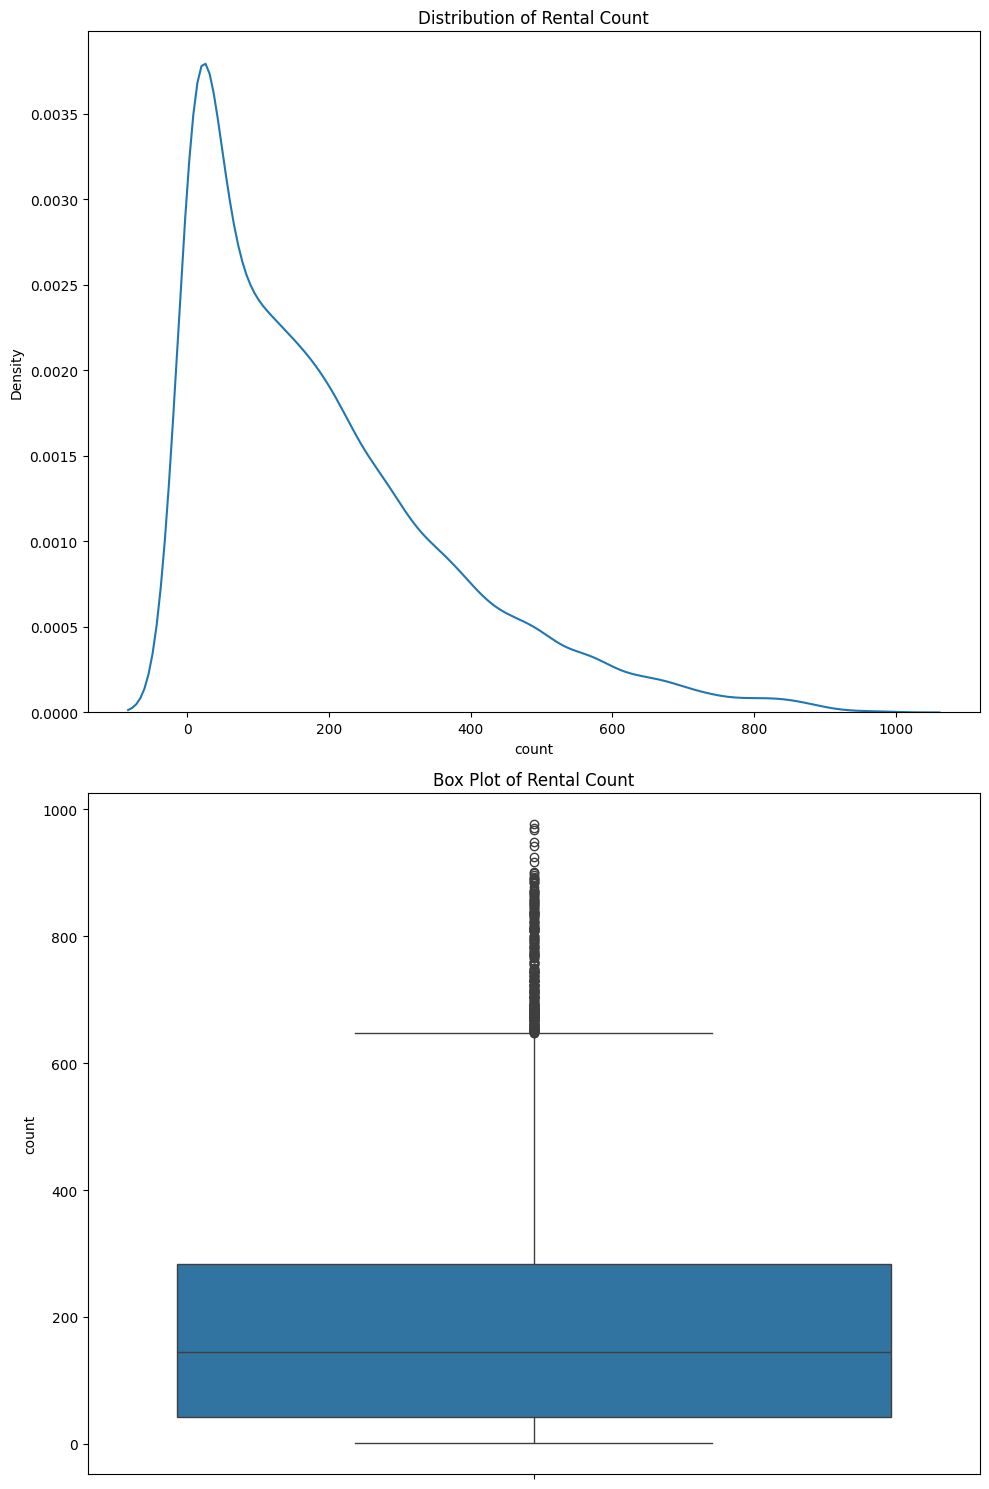

In [176]:
fig, axes = plt.subplots(2, 1, figsize = (10,15))
sns.kdeplot(df["count"], ax=axes[0])
axes[0].set_title("Distribution of Rental Count")

sns.boxplot(df["count"], ax=axes[1])
axes[1].set_title("Box Plot of Rental Count")

plt.tight_layout()
plt.show()

The rental count distribution is right-skewed, with a long upper tail and many high-value outliers, indicating occasional peak-demand days.

The median is much closer to the lower quartile, showing that most days have low to moderate rentals.

Numerous upper outliers suggest special conditions (weekends, holidays, favorable weather) drive unusually high demand.

2. Temp

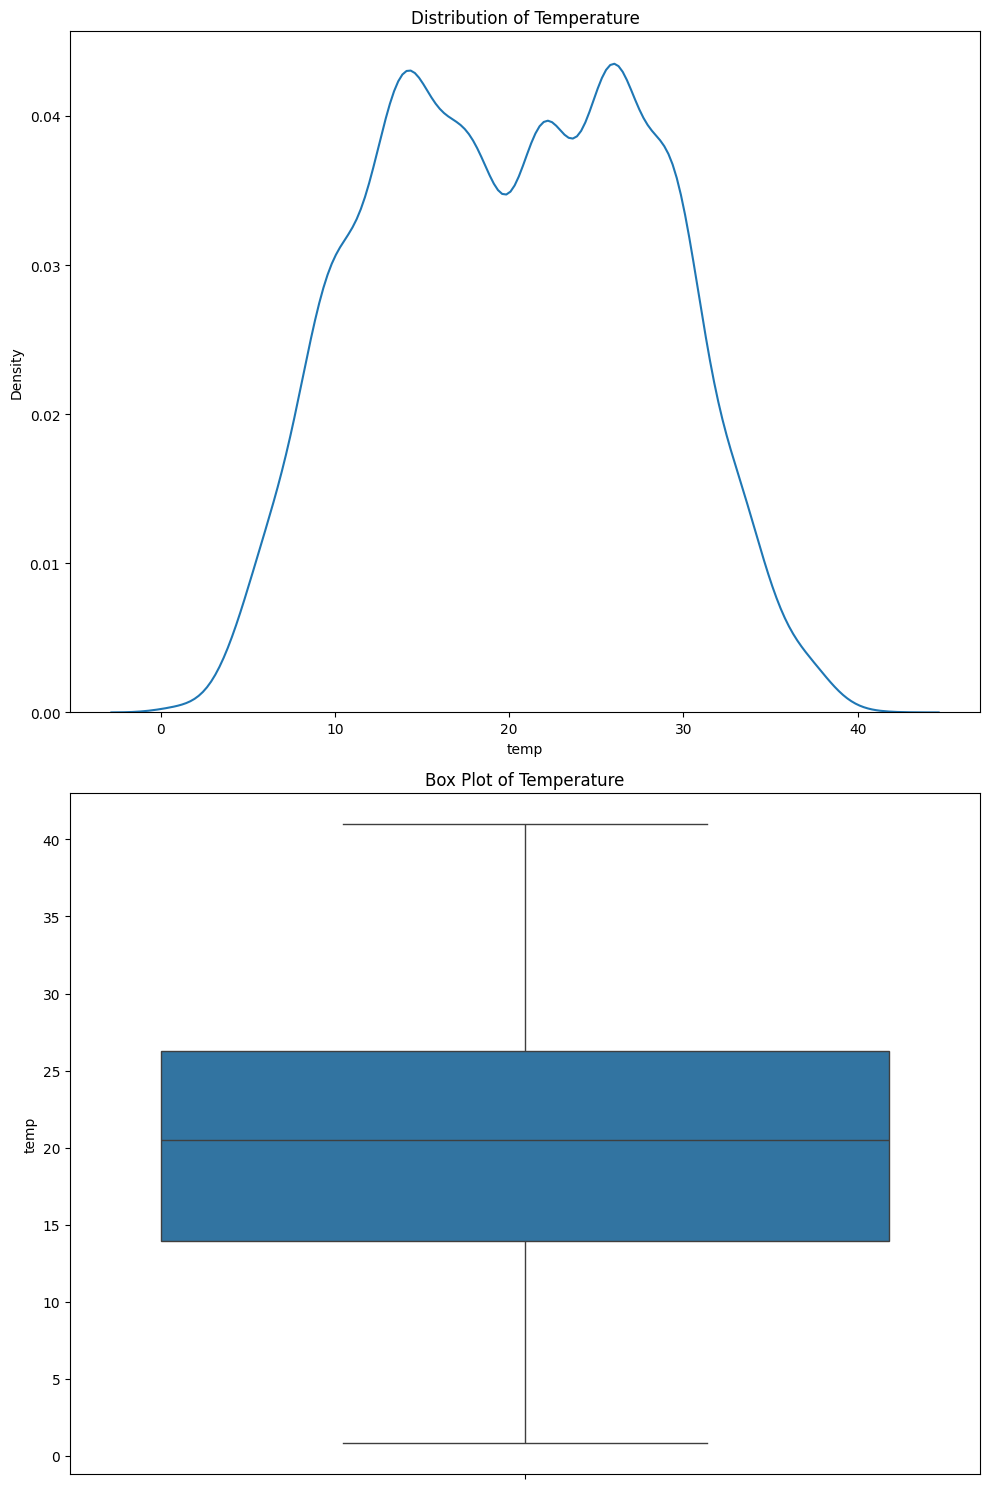

In [177]:
fig, axes = plt.subplots(2, 1, figsize = (10,15))
sns.kdeplot(df["temp"], ax=axes[0])
axes[0].set_title("Distribution of Temperature")
sns.boxplot(df["temp"], ax=axes[1])
axes[1].set_title("Box Plot of Temperature")
plt.tight_layout()
plt.show()

Temperature values are moderately spread with a median around 20°C, indicating most days have comfortable weather conditions.

The distribution is fairly symmetric, with no extreme outliers, suggesting stable temperature patterns across the dataset.

The wide range (from very low to high temperatures) reflects seasonal variation, making temperature a meaningful factor for rental analysis.

3. atemp

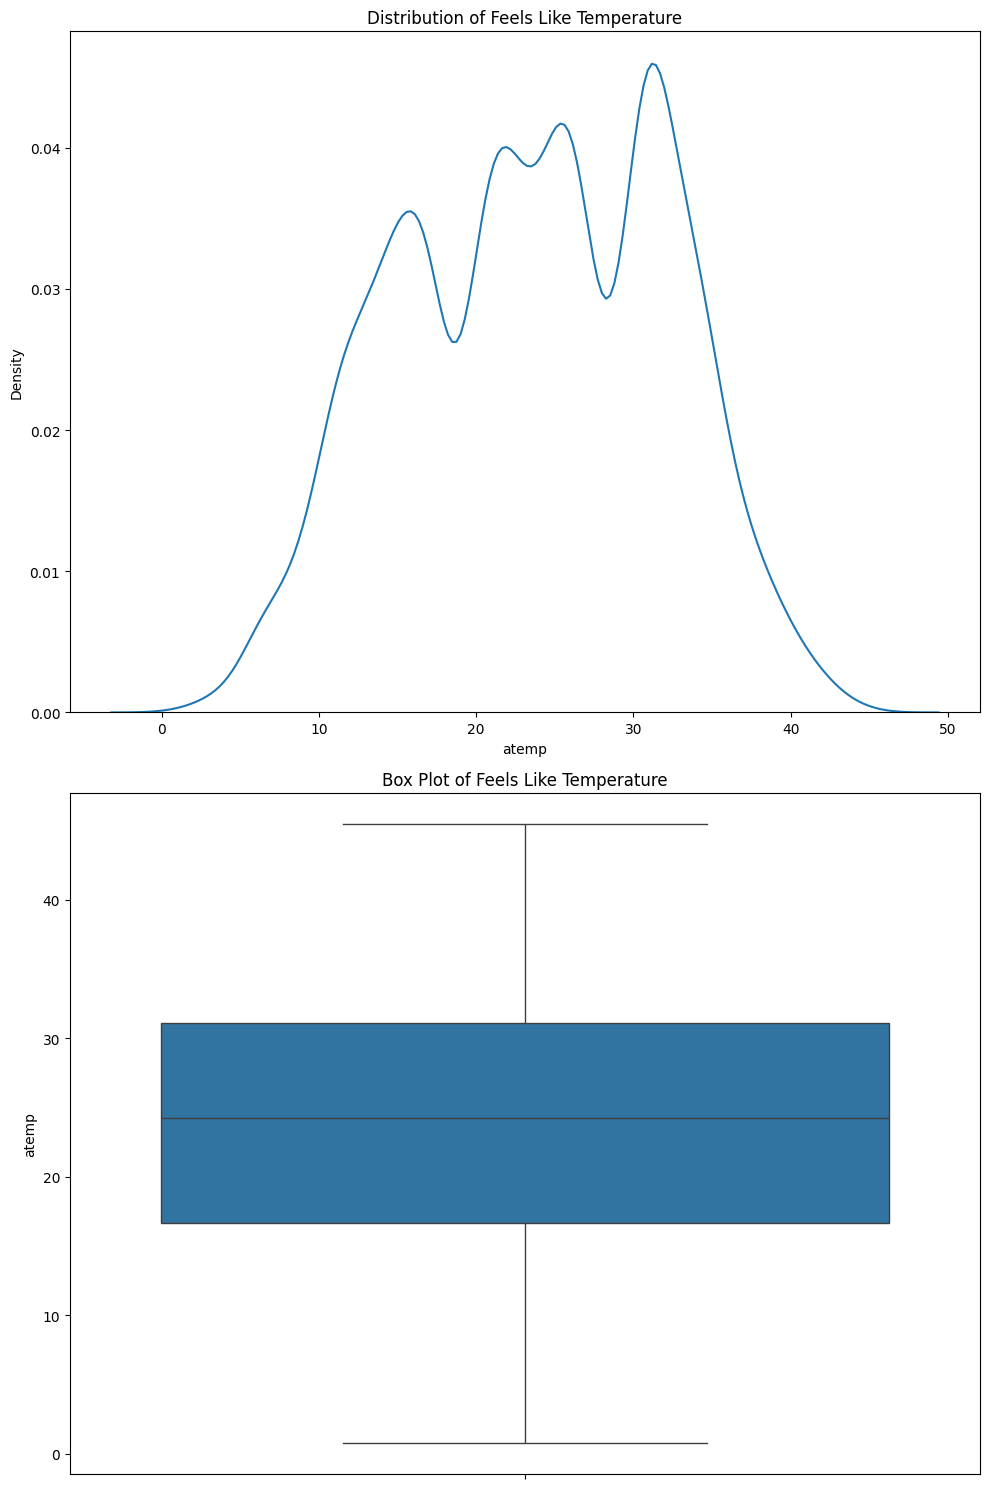

In [178]:
fig, axes = plt.subplots(2, 1, figsize = (10,15))
sns.kdeplot(df["atemp"], ax=axes[0])
axes[0].set_title("Distribution of Feels Like Temperature")
sns.boxplot(df["atemp"], ax=axes[1])
axes[1].set_title("Box Plot of Feels Like Temperature")
plt.tight_layout()
plt.show()

The median feels-like temperature is around 24°C, indicating generally comfortable perceived weather conditions.

The distribution shows a moderate spread with no extreme outliers, suggesting stable perceived temperature across days.

The wide range reflects seasonal variation, making atemp a relevant variable for understanding rental demand.

4. Humidity


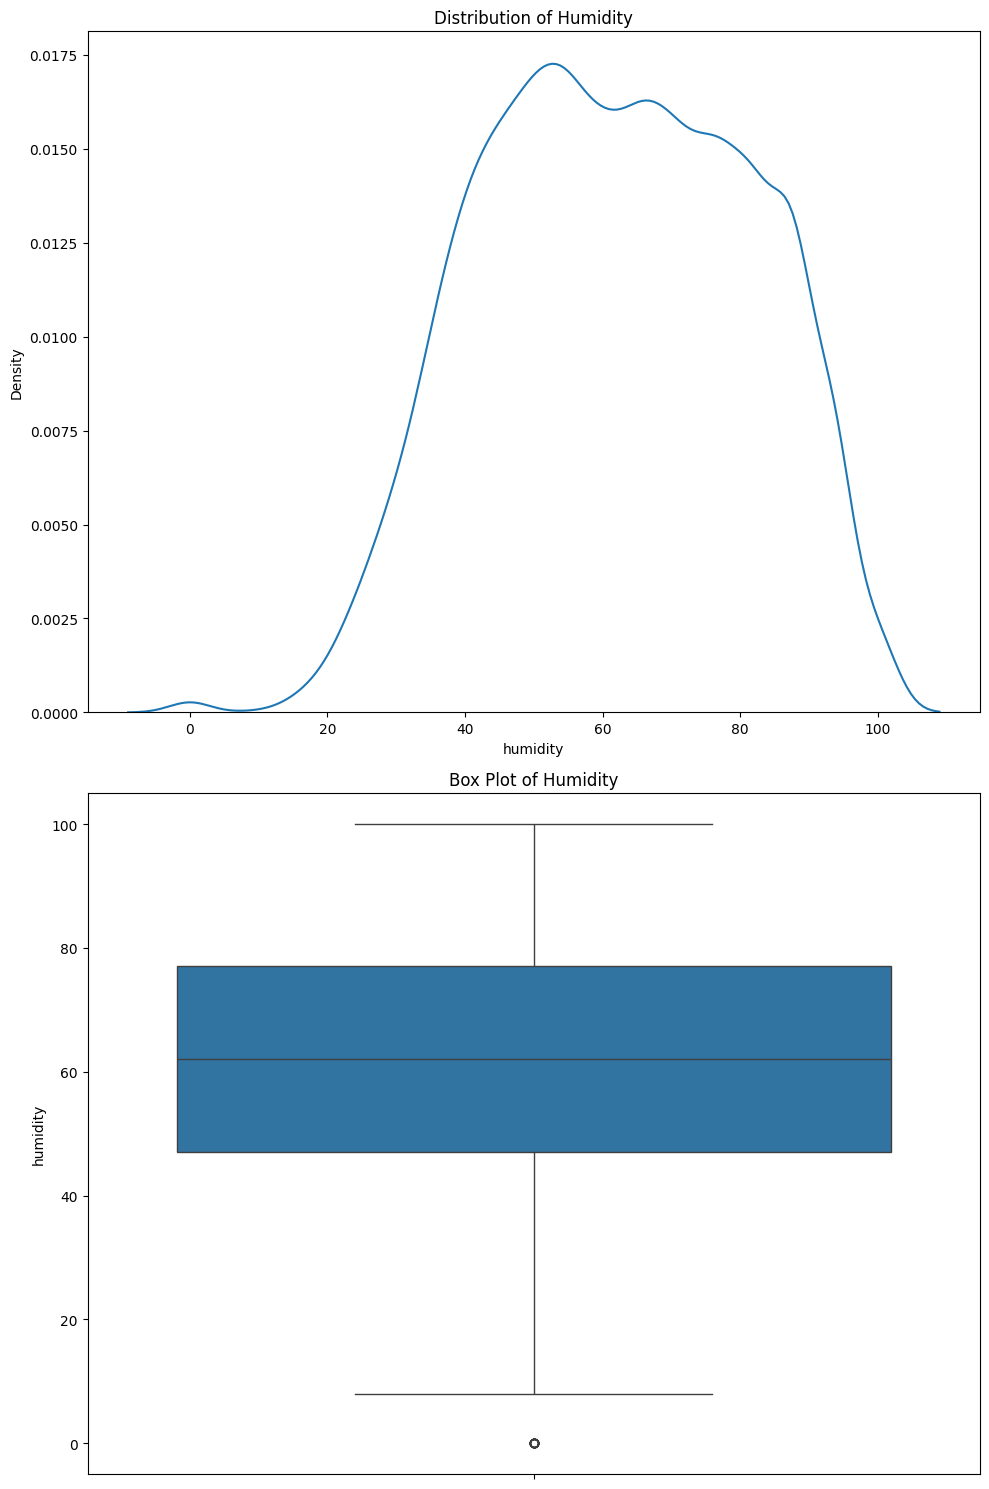

In [179]:
fig, axes = plt.subplots(2, 1, figsize = (10,15))
sns.kdeplot(df["humidity"], ax=axes[0])
axes[0].set_title("Distribution of Humidity")
sns.boxplot(df["humidity"], ax=axes[1])
axes[1].set_title("Box Plot of Humidity")
plt.tight_layout()
plt.show()

The median humidity is around 60–65%, indicating generally moderate to high humidity across most days.

The distribution shows a wide spread, reflecting substantial variability in humidity levels over time.

A few low-end outliers (very low humidity days) are present, which may correspond to unusual weather conditions.

5. Windspeed


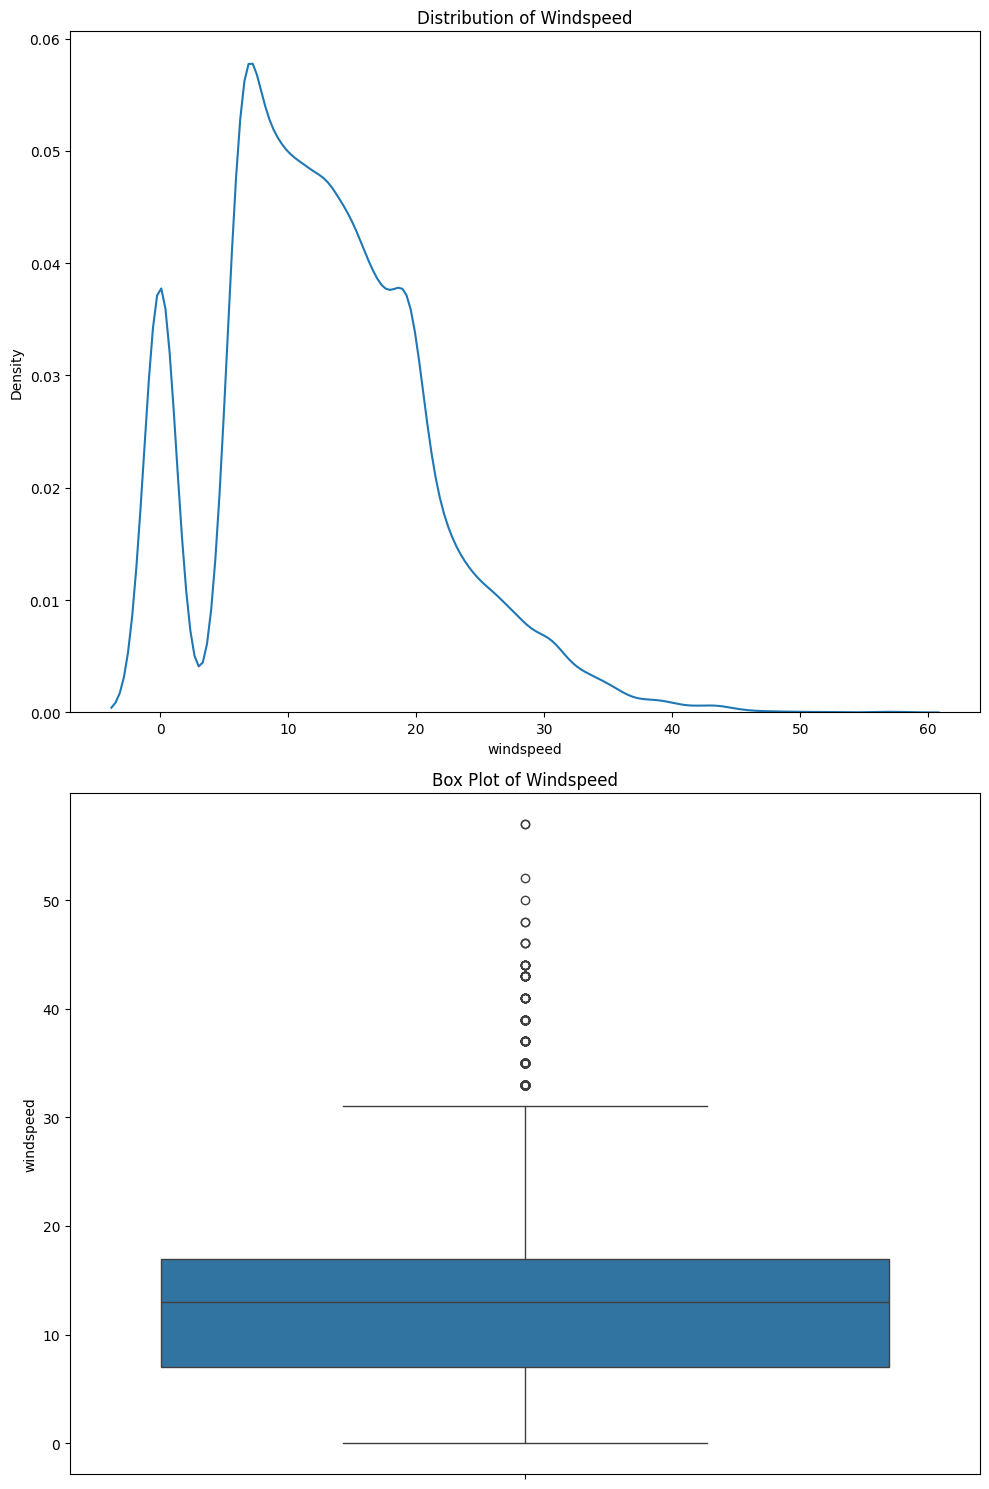

In [180]:
fig, axes = plt.subplots(2, 1, figsize = (10,15))
sns.kdeplot(df["windspeed"], ax=axes[0])
axes[0].set_title("Distribution of Windspeed")
sns.boxplot(df["windspeed"], ax=axes[1])
axes[1].set_title("Box Plot of Windspeed")
plt.tight_layout()
plt.show()

The median windspeed is around 12–13, indicating generally moderate wind conditions.

The distribution is right-skewed, with several high-value outliers, representing unusually windy days.

Most observations lie within a narrow lower range, suggesting extreme wind conditions are relatively rare.

Perform univariate analysis on categorical variables

1. workingday

Text(0.5, 1.0, 'Working Day')

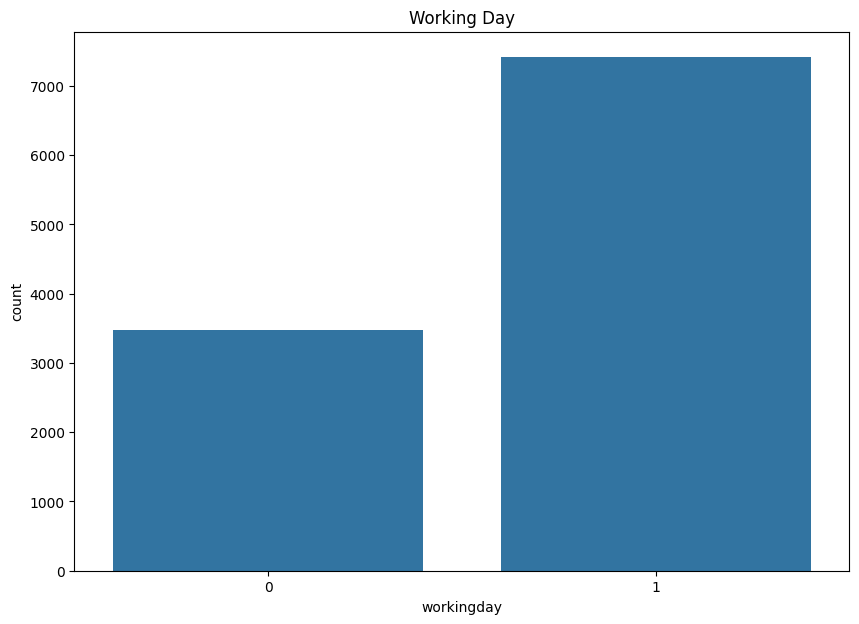

In [181]:
fig, ax = plt.subplots(figsize = (10,7))
sns.countplot(x=df["workingday"], ax=ax)
plt.title("Working Day")

Working days (1) occur much more frequently than non-working days (0), indicating the dataset is dominated by weekdays.

The imbalance suggests rental patterns may differ significantly between working and non-working days.

workingday is an important categorical variable and should be considered when analyzing or modeling rental demand.

2. season

([<matplotlib.axis.XTick at 0x7a888290a8d0>,
 [Text(0, 0, 'Spring'),
  Text(1, 0, 'Summer'),
  Text(2, 0, 'Fall'),
  Text(3, 0, 'Winter')])

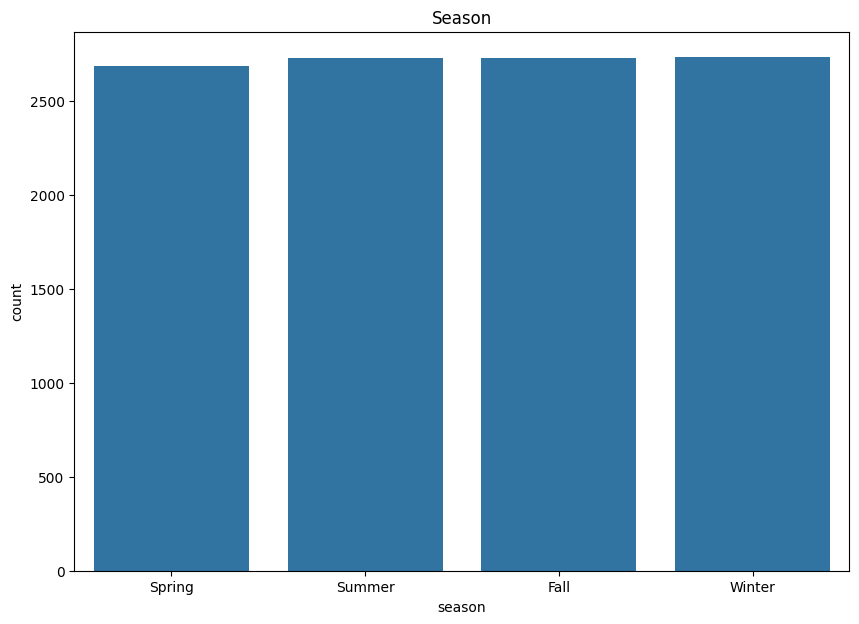

In [182]:
plt.figure(figsize = (10,7))
sns.countplot(x=df["season"])
plt.title("Season")
plt.xticks([0,1,2,3], ["Spring","Summer","Fall","Winter"])

All four seasons have almost equal number of observations, indicating a well-balanced seasonal dataset.

This balance reduces seasonal bias and supports fair comparison of rental behavior across seasons.

Season is a reliable categorical feature for analyzing and modeling rental demand.

3. weather

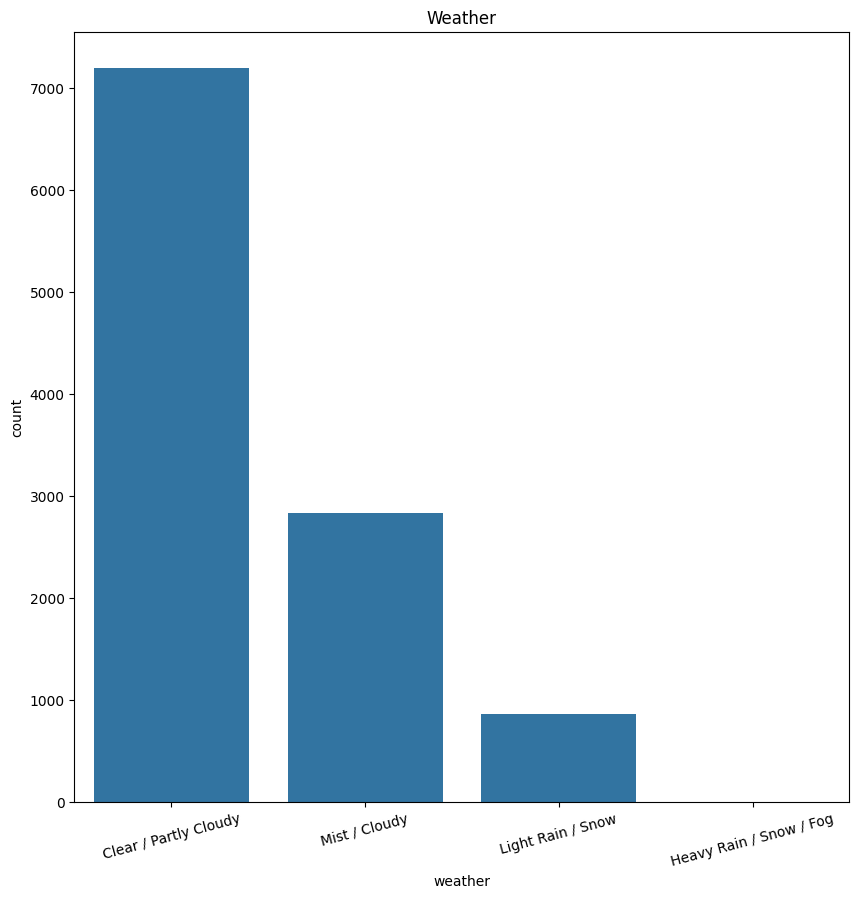

In [183]:
plt.figure(figsize = (10,10))
sns.countplot(x=df["weather"])
plt.title("Weather")
plt.xticks([0,1, 2 ,3], ['Clear / Partly Cloudy', 'Mist / Cloudy', 'Light Rain / Snow', 'Heavy Rain / Snow / Fog'], rotation = 15)
plt.show()

Clear / Partly Cloudy days dominate the dataset, indicating most rentals occur under favorable weather conditions.

Mist / Cloudy conditions occur moderately often, while Light Rain / Snow days are relatively few.

Severe weather (Heavy Rain / Snow / Fog) is extremely rare, which may limit its impact analysis due to low sample size.

4. holiday

Text(0.5, 1.0, 'Holiday')

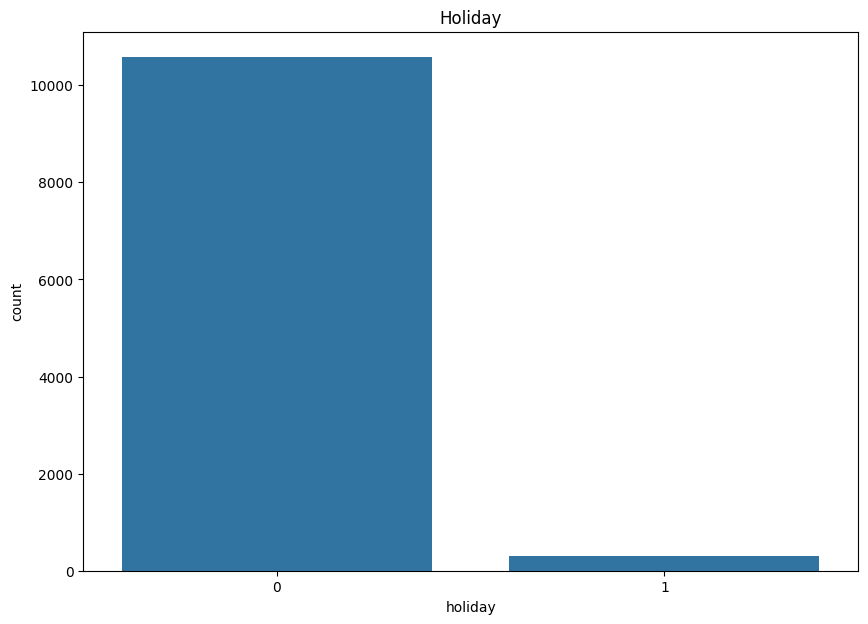

In [184]:
plt.figure(figsize = (10,7))
sns.countplot(x=df["holiday"])
plt.title("Holiday")

Non-holiday days (0) overwhelmingly dominate the dataset, while holidays (1) are very rare.

The strong class imbalance suggests holiday effects on rentals may be harder to estimate reliably.

Holiday should be treated carefully in analysis, possibly combined with workingday or used as a binary indicator.

Perform bivariate analysis between key variables

How does working day vs count vary?

Text(0.5, 1.0, 'Working Day vs Count')

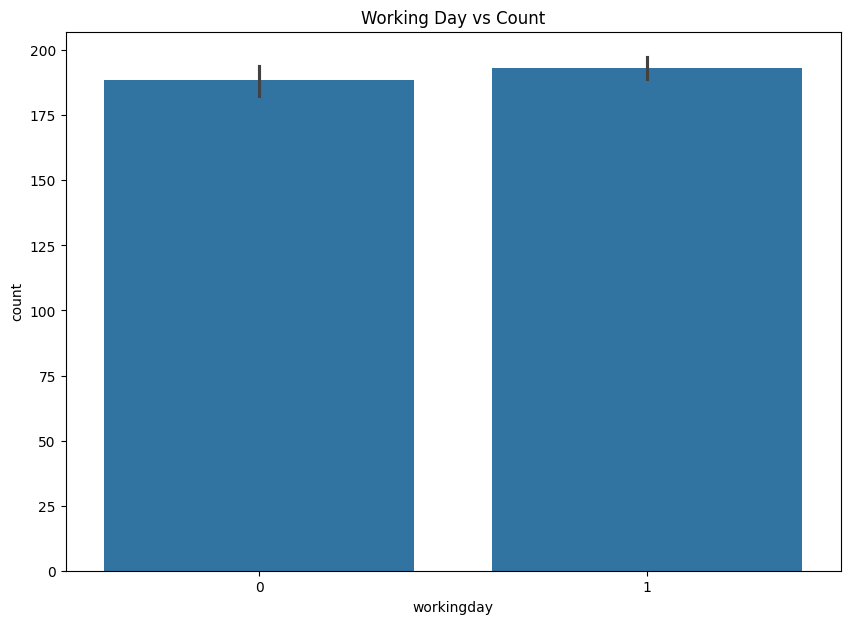

In [185]:
plt.figure(figsize = (10,7))
sns.barplot(x=df["workingday"], y=df["count"])
plt.title("Working Day vs Count")

Average rental counts are slightly higher on working days compared to non-working days.

The difference between the two groups is small, suggesting limited practical impact.

Further statistical testing (e.g., t-test or ANOVA) is needed to confirm if this difference is statistically significant.

How does season vs count vary?

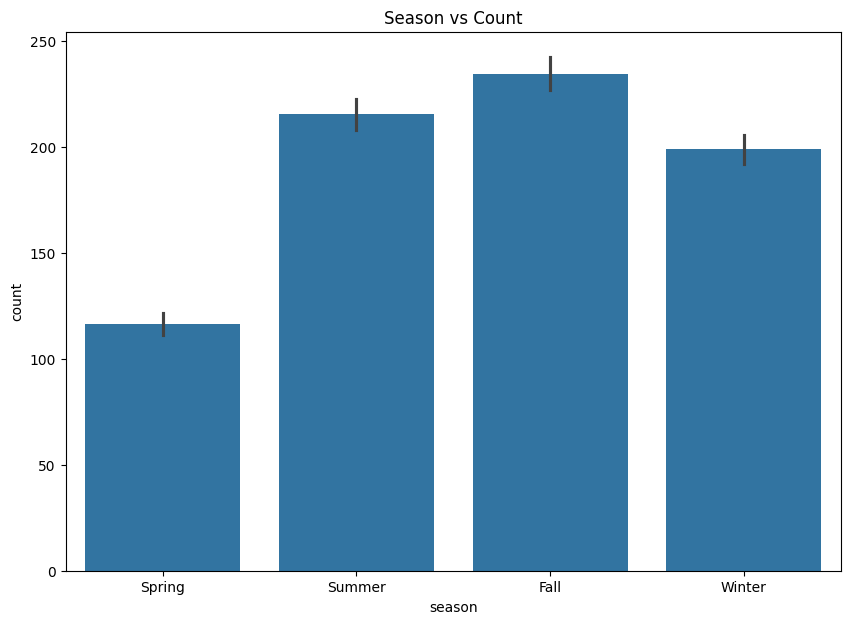

In [186]:
plt.figure(figsize = (10,7))
sns.barplot(x=df["season"], y=df["count"])
plt.title("Season vs Count")
plt.xticks([0,1,2,3], ["Spring","Summer","Fall","Winter"])
plt.show()

Rental demand is lowest in Spring and highest in Fall, indicating strong seasonal variation in usage.

Summer and Winter show moderate to high rental counts, suggesting favorable demand outside extreme conditions.

Season appears to be an important driver of rental demand, warranting further statistical testing (e.g., ANOVA).

How does weather vs count vary?

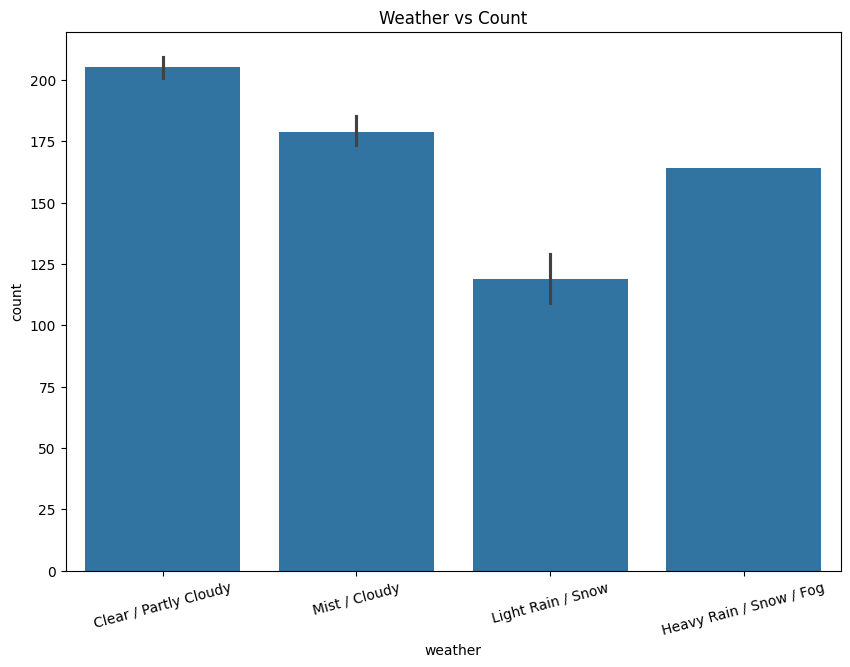

In [187]:
plt.figure(figsize = (10,7))
sns.barplot(x=df["weather"], y=df["count"])
plt.title("Weather vs Count")
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        'Clear / Partly Cloudy',
        'Mist / Cloudy',
        'Light Rain / Snow',
        'Heavy Rain / Snow / Fog'
    ],
    rotation=15
)
plt.show()

Rental demand is highest during Clear / Partly Cloudy weather and declines as weather conditions worsen.

Light Rain / Snow shows the lowest average rentals, indicating strong negative impact of adverse weather.

Weather is a key factor influencing demand, suitable for inclusion in hypothesis testing (e.g., ANOVA).

Part A: 2-Sample T-Test

In [188]:
from scipy.stats import ttest_ind

Does a working day have a significant effect on the number of electric cycles rented?

•	H0 (Null Hypothesis):
Mean rentals on working days is equal to mean rentals on non-working days

•	H1 (Alternate Hypothesis):
Mean rentals on working days is not equal to mean rentals on non-working days


In [189]:
working_days = df[(df["workingday"]==1)]["count"]
non_working_days = df[(df["workingday"]==0)]["count"]

Normality Checking Using Shapiro & QQ Plot

In [190]:
from scipy.stats import shapiro

NON Working Days

• H0 (Null Hypothesis): Distribution of non_working days is Normal

• H1 (Alternate Hypothesis): Distribution of non_working days is not Normal

In [191]:
stats , p_value = shapiro(non_working_days)
print("P_value :",p_value)

P_value : 4.4728547627911074e-45


In [192]:
if p_value < 0.05:
    print("Reject the null hypothesis")
    print("Distribution of non_working days is not Normal")
else:
  print("Failed To Reject null hypothesis")
  print("Distribution of non_working days is Normal")

Reject the null hypothesis
Distribution of non_working days is not Normal


In [193]:
!pip install statsmodels

In [194]:
from statsmodels.graphics.gofplots import qqplot

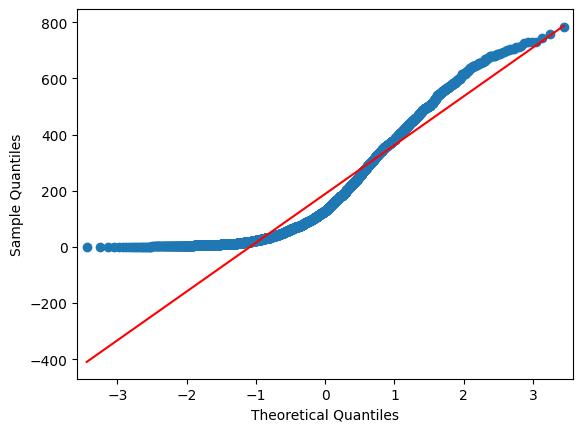

In [141]:
qqplot(non_working_days,line = "s")
plt.show()

In [142]:
mean_non_working_days = []
for i in range(1000):
  working_days_count = np.random.choice(non_working_days,size = 150)
  mean_non_working_days.append(np.mean(working_days_count))

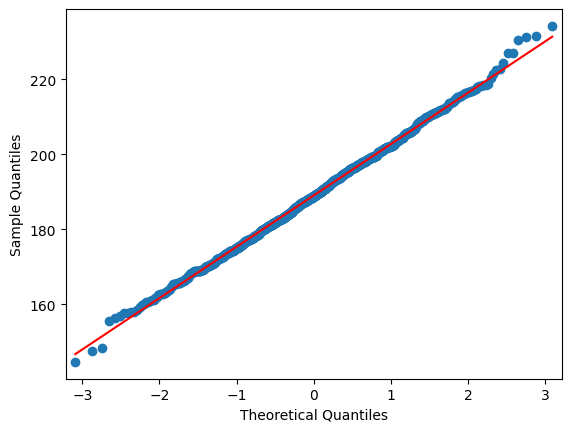

In [143]:
qqplot(np.array(mean_non_working_days),line = "s")
plt.show()

In [196]:
stats ,p_value = shapiro(mean_non_working_days)
print("Stats:", stats)
print("P_value :",p_value)

Stats: 0.9986432323724098
P_value : 0.6502206191570544


In [197]:
if p_value < 0.05:
    print("Reject the null hypothesis")
    print("Distribution of non_working days is not Normal")
else:
  print("Failed To Reject null hypothesis")
  print("Distribution of non_working days is Normal")

Failed To Reject null hypothesis
Distribution of non_working days is Normal


Rental demand on non-working days is stable and predictable, without extreme fluctuations.

This consistency allows reliable planning for bike availability and staffing on weekends and holidays.

Standard forecasting and pricing strategies can be applied confidently for non-working days.

Working Days

• H0 (Null Hypothesis): Distribution of non_working days is Normal

• H1 (Alternate Hypothesis): Distribution of non_working days is not Normal

In [ ]:
stats , p_value = shapiro(working_days)
print("P_value :",p_value)

P_value : 2.2521124830019574e-61


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7412.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
if p_value < 0.05:
    print("Reject the null hypothesis")
    print("Distribution of working days is not Normal")
else:
  print("Failed To Reject null hypothesis")
  print("Distribution of working days is Normal")

Reject the null hypothesis
Distribution of working days is not Normal


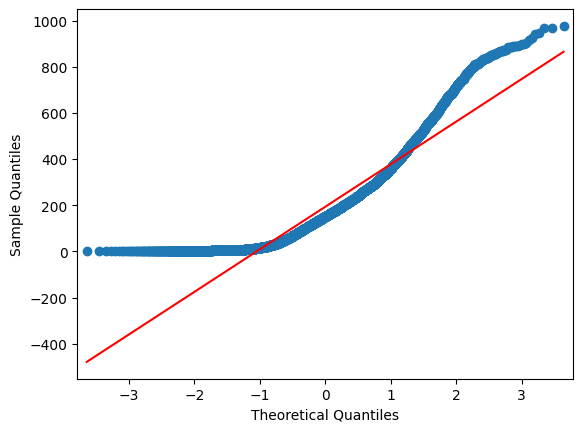

In [ ]:
qqplot(working_days,line = "s")
plt.show()

In [ ]:
mean_working_days = []
for i in range (1000):
  working_days_count = np.random.choice(working_days,size = 120)
  mean_working_days.append(np.mean(working_days_count))

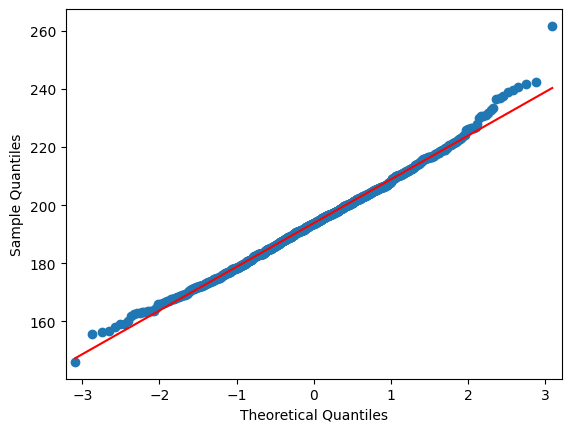

In [ ]:
qqplot(np.array(mean_working_days),line = "s")
plt.show()

In [ ]:
stats , p_value = shapiro(mean_working_days)
print("P_value :",p_value)

P_value : 0.6623089596824958


In [ ]:
if p_value < 0.05:
    print("Reject the null hypothesis")
    print("Distribution of working days is not Normal")
else:
  print("Failed To Reject null hypothesis")
  print("Distribution of working days is Normal")

Failed To Reject null hypothesis
Distribution of working days is Normal


In [ ]:
t_stats, p_value = ttest_ind(mean_working_days, mean_non_working_days)
print("t-statistics :",round(t_stats,2))
print("p-value :",p_value)

t-statistics : 7.09
p-value : 1.9151426829547473e-12


In [ ]:
if p_value < 0.05:
    print("Reject the null hypothesis")
    print("Mean rentals on working days is not equal to mean rentals on non-working days")
else:
    print("Fail to reject the null hypothesis")
    print("Mean rentals on working days is equal to mean rentals on non-working days")

Reject the null hypothesis
Mean rentals on working days is not equal to mean rentals on non-working days


Rental demand differs between working and non-working days, indicating user behavior changes based on day type.

Working days likely reflect commute-driven usage, while non-working days reflect leisure-driven usage.

This insight supports different operational and pricing strategies for weekdays versus weekends/holidays.

Part B: ANOVA – Season & Weather

In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 9.2 MB/s eta 0:00:00


In [ ]:
import pingouin as pg

In [ ]:
from scipy.stats import f_oneway

Is the number of cycles rented similar or different across different seasons?

	H0: Mean rentals are same across all seasons
	H1: Mean rentals are not same across all seasons or at least one season


In [ ]:
df["season"].value_counts()

,count
season,
4,2734
2,2733
3,2733
1,2686


In [145]:
spring = df[(df["season"] == 1)]["count"]
summer = df[(df["season"] == 2)]["count"]
fall = df[(df["season"] == 3)]["count"]
winter = df[(df["season"] == 4)]["count"]

Normality Checking


H0 : Distribution is Normal

H1 : Distribution is not Normal

In [146]:
Season_data_dict = {
    "spring" : spring,
    "summer" : summer,
    "fall"   : fall,
    "winter" : winter
}


Season: spring
P-value: 8.749584618867662e-49
Reject the null hypothesis
Distribution of spring is NOT Normal


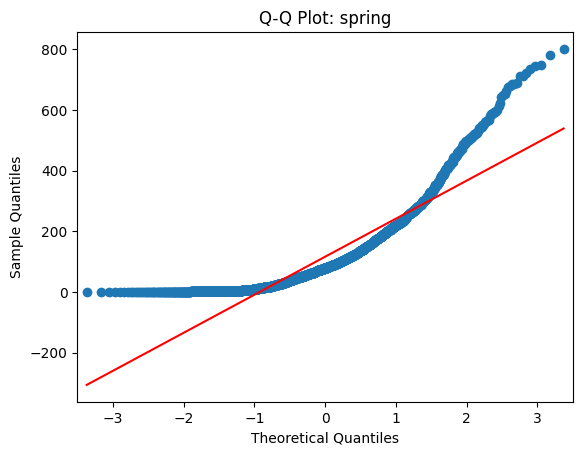


Season: summer
P-value: 6.039374406270491e-39
Reject the null hypothesis
Distribution of summer is NOT Normal


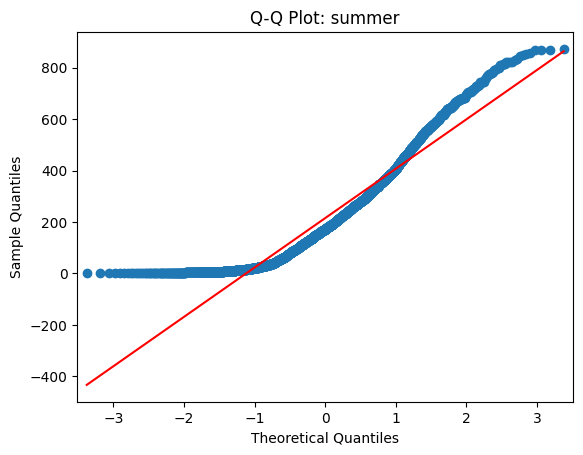


Season: fall
P-value: 1.043680518918597e-36
Reject the null hypothesis
Distribution of fall is NOT Normal


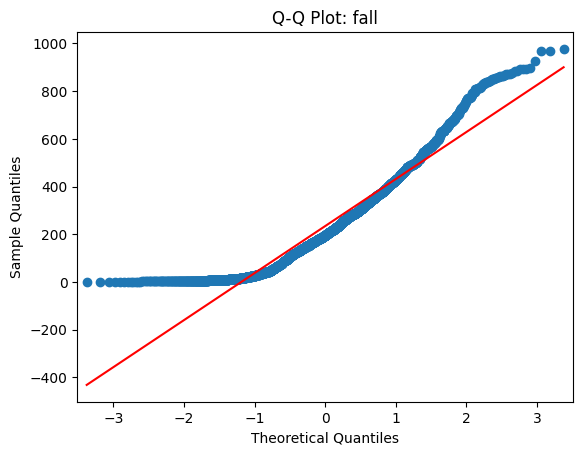


Season: winter
P-value: 1.1299244409282836e-39
Reject the null hypothesis
Distribution of winter is NOT Normal


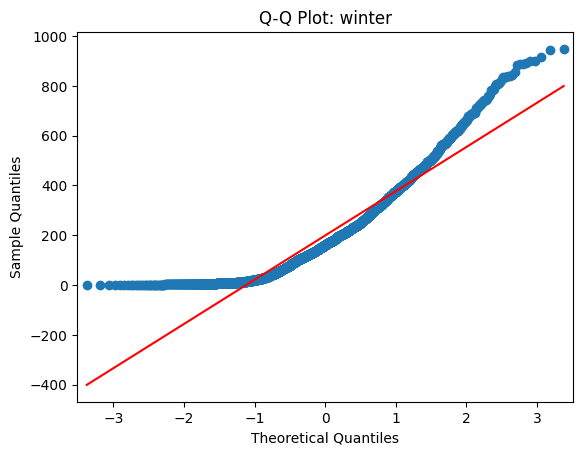

In [147]:
for season_name, season_data in Season_data_dict.items():

  stat, p_value = shapiro(season_data)
  print(f"\nSeason: {season_name}")
  print("P-value:", p_value)

  if p_value < 0.05:
    print("Reject the null hypothesis")
    print(f"Distribution of {season_name} is NOT Normal")
  else:
    print("Failed to reject null hypothesis")
    print(f"Distribution of {season_name} is Normal")

  qqplot(season_data, line="s")
  plt.title(f"Q-Q Plot: {season_name}")
  plt.show()

Levene Test ( Testing Equal Variance )

H0 : Variance are same

H1 : Variance are not same

In [148]:
from scipy.stats import levene

In [ ]:
levene_stats, p_value = levene(spring, summer, fall, winter)
print("Levene Test :",levene_stats)
print("Pvalue :",p_value)

Levene Test : 187.7706624026276
Pvalue : 1.0147116860043298e-118


In [ ]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("Variance is not same")
else:
  print("Fail to reject the null")
  print("Variance is same")

Reject the null hypothesis
Variance is not same


In [149]:
from scipy.stats import kruskal

In [151]:
F_stats , p_value = kruskal(spring,summer,fall,winter)
print("F-statistics :",F_stats)
print("Pvalue :",p_value)

F-statistics : 699.6668548181988
Pvalue : 2.479008372608633e-151


In [152]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("Mean rentals are not same across all seasons or at least one seasons")
else:
  print("Fail to reject the null")
  print("Mean rentals are same across all seasons")

Reject the null hypothesis
Mean rentals are not same across all seasons or at least one seasons


Rental demand varies significantly by season, indicating strong seasonal usage patterns.

Certain seasons drive higher demand, requiring increased bike availability and staffing.

Seasonal trends should be explicitly incorporated into demand forecasting and pricing strategies.

Is the number of cycles rented similar or different across different weather conditions?

In [ ]:
df["weather"].value_counts()

,count
weather,
1,7192
2,2834
3,859
4,1


H0 : Mean Rentals are same across all weather

H1 : Mean Rentals are different across all weather or at least one weather

In [ ]:
Clear_or_Partly_Cloudy = df[(df['weather'] == 1)]["count"]
Mist_or_Cloudy = df[(df['weather'] == 2)]["count"]
Light_Rain_or_Snow = df[(df['weather'] == 3)]["count"]
Heavy_Rain_or_Snow_or_Fog = df[(df['weather'] == 4)]["count"]

Normality Checking

In [ ]:
Weather_data = {
        'Clear / Partly Cloudy' : Clear_or_Partly_Cloudy,
        'Mist / Cloudy' : Mist_or_Cloudy,
        'Light Rain / Snow' : Light_Rain_or_Snow,
        'Heavy Rain / Snow / Fog' : Heavy_Rain_or_Snow_or_Fog
}

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7192.
  res = hypotest_fun_out(*samples, **kwds)



Weather: Clear / Partly Cloudy
P-value: 1.5964921477006555e-57
Reject the null hypothesis
Distribution of Clear / Partly Cloudy is NOT Normal


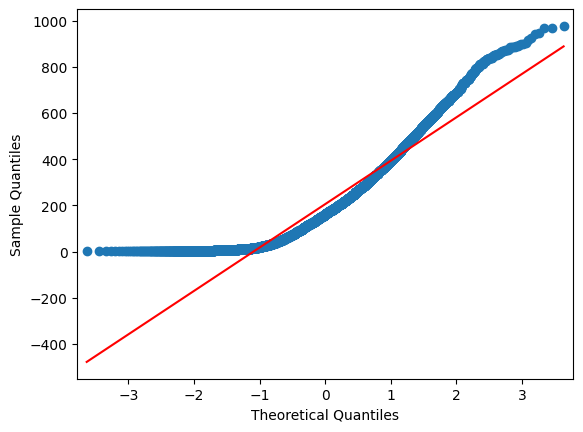


Weather: Mist / Cloudy
P-value: 9.777839106111785e-43
Reject the null hypothesis
Distribution of Mist / Cloudy is NOT Normal


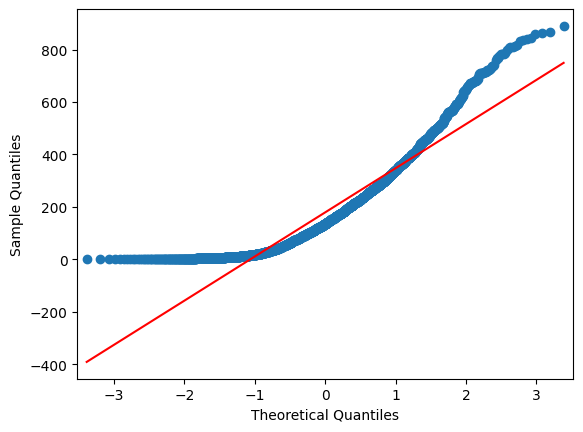


Weather: Light Rain / Snow
P-value: 3.875893017396149e-33
Reject the null hypothesis
Distribution of Light Rain / Snow is NOT Normal


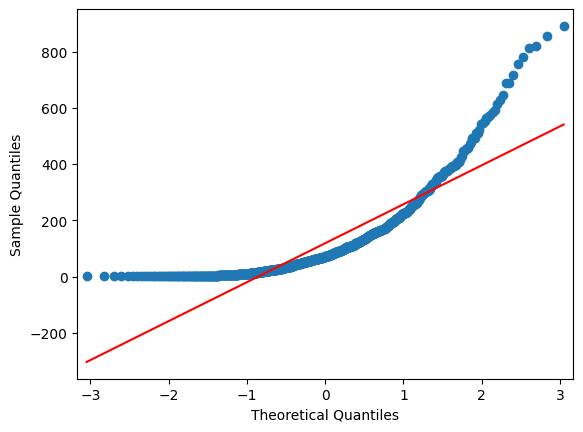


Weather: Heavy Rain / Snow / Fog
P-value: nan
Failed to reject null hypothesis
Distribution of Heavy Rain / Snow / Fog is Normal


/tmp/ipython-input-1039276777.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  F_stats, p_value = shapiro(weather_data)


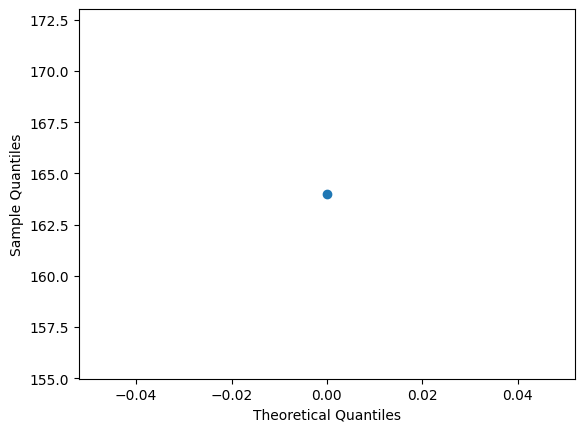

In [ ]:
for weather_name, weather_data in Weather_data.items():
  F_stats, p_value = shapiro(weather_data)
  print(f"\nWeather: {weather_name}")
  print("P-value:", p_value)

  if p_value < 0.05:
    print("Reject the null hypothesis")
    print(f"Distribution of {weather_name} is NOT Normal")

  else:
    print("Failed to reject null hypothesis")
    print(f"Distribution of {weather_name} is Normal")

  qqplot(weather_data, line="s")
  plt.show()

Levene Test ( Equal Variance Test )

H0 : Variance is Same

H1 : Variance is not same

In [ ]:
levene_test, p_value = levene(Clear_or_Partly_Cloudy, Mist_or_Cloudy, Light_Rain_or_Snow, Heavy_Rain_or_Snow_or_Fog)
print("Levene Test :",levene_test)
print("Pvalue :",p_value)

Levene Test : 54.85106195954556
Pvalue : 3.504937946833238e-35


In [ ]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("Variance is not same")
else:
  print("Fail to reject the null")
  print("Variance is same")

Reject the null hypothesis
Variance is not same


In [ ]:
F_stats , p_value = kruskal(Clear_or_Partly_Cloudy, Mist_or_Cloudy, Light_Rain_or_Snow, Heavy_Rain_or_Snow_or_Fog)
print("F-statistics :",F_stats)
print("Pvalue :",p_value)

F-statistics : 205.00216514479087
Pvalue : 3.501611300708679e-44


In [ ]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("Mean Rentals are not same across all weather or at least one weather")
else:
  print("Fail to reject the null")
  print("Mean Rentals are same across all weather")

Reject the null hypothesis
Mean Rentals are different across all weather or at least one weather


Rental demand changes significantly with weather conditions, confirming weather as a key demand driver.

Clear and mild weather supports higher usage, while adverse weather reduces demand.

Operations and supply planning should be weather-aware, with dynamic allocation and incentives.

2 way Anova

Main Effect :

1. Is there any significant effect between Weather and Rentals
2. Is there any significant effect between Season and Rentals

Interaction Effect :               

1. Is there any interaction between Weather and Season

In [ ]:
grp_data = df.groupby(["season","weather"]).size()
grp_data

/tmp/ipython-input-3628247394.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp_data = df.groupby(["season","weather"]).size()


season  weather
1       1          1759
        2           715
        3           211
        4             1
2       1          1801
        2           708
        3           224
        4             0
3       1          1930
        2           604
        3           199
        4             0
4       1          1702
        2           807
        3           225
        4             0
dtype: int64

In [ ]:
df1 = df[(df['weather'] != 4)]

In [ ]:
df1.dtypes

,0
datetime,object
season,category
holiday,category
workingday,category
weather,category
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


Main Effect :

1. Is there any significant effect between Weather and Rentals?

H0 : Mean Rentals are same across different weather

H1 : Mean Rentals are not same across different weather



2. Is there any significant effect between Season and Rentals?

H0 : Mean Rentals are same across different season

H1 : Mean Rentals are not same across different season



Interaction Effect :

1. Is there any interaction between Weather and Season?

H0 : There is no interaction between Season and Weather

H1 : There is interaction between Season and Weather


In [ ]:
model = pg.anova (data=df1, dv='count', between=['season', 'weather'], ss_type = 2)
model

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 2
  warnings.warn('covariance of constraints does not have full '


,Source,SS,DF,MS,F,p-unc,np2
0,season,-3.171966e-06,3.0,-0.000001,-3.497213e-11,1.000000,-9.649258e-15
1,weather,3.254415e-04,3.0,0.000108,3.588117e-09,1.000000,9.900074e-13
2,season * weather,2.029107e+05,9.0,22545.635338,7.457226e-01,0.474416,6.168825e-04
3,Residual,3.287264e+08,10873.0,30233.272000,NaN,NaN,NaN


In [198]:
model1 = model.loc[0:2,["Source","p-unc"]]
model1

,Source,p-unc
0,season,1.000000
1,weather,1.000000
2,season * weather,0.474416


In [ ]:
if model1.loc[0,"p-unc"] < 0.05:
  print("Reject the null hypothesis")
  print("Mean Rentals are not same across different weather")
else:
  print("Fail to reject the null hypothesis")
  print("Mean Rentals are same across different weather")

Fail to reject the null hypothesis
Mean Rentals are same across different weather


In [ ]:
if model1.loc[1,"p-unc"] < 0.05:
  print("Reject the null hypothesis")
  print("Mean Rentals are not same across different season")
else:
  print("Fail to reject the null hypothesis")
  print("Mean Rentals are same across different season")

Fail to reject the null hypothesis
Mean Rentals are same across different season


In [ ]:
if model1.loc[2,"p-unc"] < 0.05:
  print("Reject the null hypothesis")
  print("There is interaction between Season and Weather")
else:
  print("Fail to reject the null hypothesis")
  print("There is no interaction between Season and Weather")

Fail to reject the null hypothesis
There is no interaction between Season and Weather


Rental demand is not materially driven by season or weather alone in this data.

Other factors (e.g., registered users, working day, time patterns) dominate demand behavior.

Operational or pricing strategies based solely on season or weather are unlikely to yield strong gains.

Chi-Square Test

1. Is weather dependent on season?

H₀: Weather and Season are independent

H₁: Weather and Season are associated

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
weather_season = pd.crosstab(df1["season"],df1["weather"])
weather_season

weather,1,2,3
season,,,
1,1759,715,211
2,1801,708,224
3,1930,604,199
4,1702,807,225


In [ ]:
chi_stat, p_value , df , exp_freq = chi2_contingency(weather_season)
print("Chi-Square Statistics :",chi_stat)
print("P-value :",p_value)
print("Degree of Freedom :",df)
print("Expected Frequency :",exp_freq)

Chi-Square Statistics : 46.10145731073249
P-value : 2.8260014509929343e-08
Degree of Freedom : 6
Expected Frequency : [[1774.04869086  699.06201194  211.8892972 ]
 [1805.76352779  711.55920992  215.67726229]
 [1805.76352779  711.55920992  215.67726229]
 [1806.42425356  711.81956821  215.75617823]]


In [ ]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("Weather is dependent on Season")
else:
  print("Fail to reject the null hypothesis")
  print("Weather is independent of Season")

Reject the null hypothesis
Weather is dependent on Season


2. Is Weather dependent on Working Day

H₀: Weather and Working Day are independent

H₁: Weather and Working Day are associated

In [ ]:
Weather_WorkingDay = pd.crosstab(df1["workingday"],df1["weather"])
Weather_WorkingDay

weather,1,2,3
workingday,,,
0,2353,897,224
1,4839,1937,635


In [ ]:
chi_stat, p_value, df, exp_freq = chi2_contingency(Weather_WorkingDay)
print("Chi-Square Statistics :",chi_stat)
print("P-value :",p_value)
print("Degree of Freedom :",df)
print("Expected Frequency :",exp_freq)

Chi-Square Statistics : 15.69301034055415
P-value : 0.00039111646797425055
Degree of Freedom : 2
Expected Frequency : [[2295.36132292  904.48470372  274.15397336]
 [4896.63867708 1929.51529628  584.84602664]]


In [ ]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("Weather is dependent on Working Day")
else:
  print("Fail to reject the null hypothesis")
  print("Weather is independent of Working Day")

Reject the null hypothesis
Weather is dependent on Working Day


There is a strong association between the two categories tested (e.g., Season and Weather / Working Day and Weather, depending on your test).

Certain categories co-occur more frequently than expected (e.g., specific weather patterns in certain seasons).

This relationship should be accounted for in planning and analysis, even if it does not directly translate into changes in average rentals.

3. Is Season Dependent on Working Day

H₀: Season and Working Day are independent

H₁: Season and Working Day are associated

In [ ]:
Season_WorkingDay = pd.crosstab(df1["workingday"],df1["season"])
Season_WorkingDay

season,1,2,3,4
workingday,,,,
0,858,840,888,888
1,1827,1893,1845,1846


In [ ]:
chi_stat, p_value, df, exp_freq = chi2_contingency(Season_WorkingDay)
print("Chi-Square Statistics :",chi_stat)
print("P-value :",p_value)
print("df :",df)
print("Expected Frequency :",exp_freq)

Chi-Square Statistics : 2.571808697199707
P-value : 0.4624532948503586
df : 3
Expected Frequency : [[ 856.93063849  872.2500689   872.2500689   872.5692237 ]
 [1828.06936151 1860.7499311  1860.7499311  1861.4307763 ]]


In [ ]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("Season is dependent on Working Day")
else:
  print("Fail to reject the null hypothesis")
  print("Season is independent of Working Day")

Fail to reject the null hypothesis
Season is independent of Working Day


The proportion of working vs non-working days remains consistent across seasons.

Seasonal changes do not affect workday patterns in the dataset.

Season and working-day effects on rentals can be analyzed separately without joint dependency.

Correlation Test

In [78]:
df2 = df.select_dtypes(include = "number")
df2

,temp,atemp,humidity,windspeed,casual,registered,count
0,9.84,14.395,81,0.0000,3,13,16
1,9.02,13.635,80,0.0000,8,32,40
2,9.02,13.635,80,0.0000,5,27,32
3,9.84,14.395,75,0.0000,3,10,13
4,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...
10881,15.58,19.695,50,26.0027,7,329,336
10882,14.76,17.425,57,15.0013,10,231,241
10883,13.94,15.910,61,15.0013,4,164,168
10884,13.94,17.425,61,6.0032,12,117,129


Correlation Test

In [82]:
df2.shape

(10886, 7)

In [85]:
corr = df2.corr()

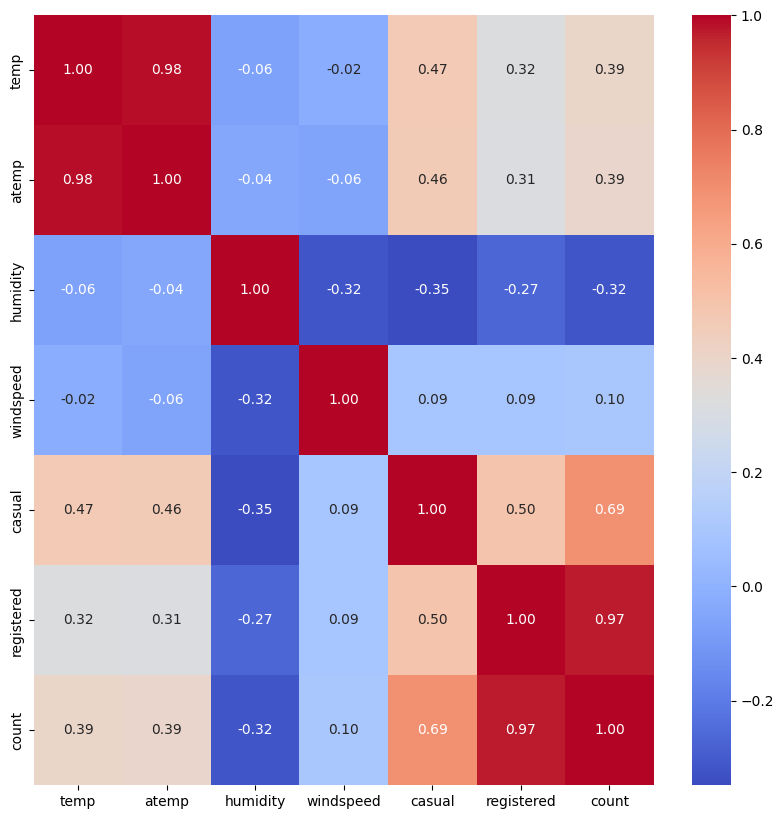

In [86]:
plt.figure(figsize = (10,10))
sns.heatmap(corr, annot = True , fmt = ".2f", cmap= "coolwarm")
plt.show()

Registered users have an extremely strong positive correlation with total rentals (count ≈ 0.97), indicating they are the primary driver of demand.

Casual users show a moderate–strong positive correlation (≈ 0.69), while temperature (≈ 0.39) also positively influences rentals, though to a lesser extent.

Humidity is negatively correlated with rentals (≈ -0.32), suggesting higher humidity tends to reduce bike usage, while windspeed has minimal impact.

In [87]:
from scipy.stats import pearsonr, spearmanr

In [88]:
df2.columns

Index(['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered',
       'count'],
      dtype='object')

1. Temp Vs Count


H0 : There is no monotonic relationship  between temp and count

H1 : There is a monotonic relationship  between temp and count

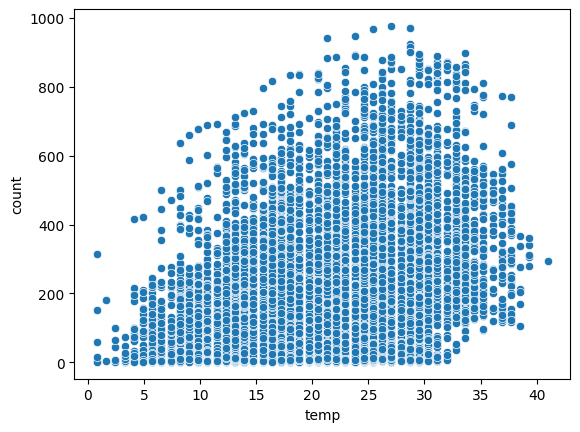

In [89]:
sns.scatterplot(x = "temp", y = "count", data = df2)
plt.show()

In [91]:
stats , p_value = spearmanr(df2["temp"],df2["count"])
print("Spearman Rank Correlation :",stats)
print("P-value :",p_value)

Spearman Rank Correlation : 0.40798939475098117
P-value : 0.0


In [156]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("There is a monotonic relationship relationship between temp and count")
else:
  print("Fail to reject the null hypothesis")
  print("There is no monotonic relationship relationship between temp and count")

Reject the null hypothesis
There is a monotonic relationship relationship between temp and count


Higher temperatures are associated with increased bike rentals, supporting weather-driven demand planning.

Demand rises steadily with temperature, but not at a constant rate, indicating comfort thresholds.

Temperature should be included as a key input in demand forecasting models, preferably with non-linear handling.

2. atemp vs count

H0 : There is no monotonic relationship between atemp & count

H1 : There is monotonic relationship between atemp & count

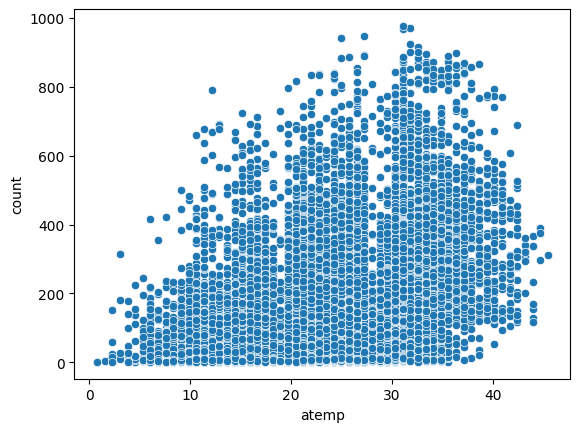

In [92]:
sns.scatterplot(x = "atemp", y = "count", data = df2)
plt.show()

In [93]:
stats , p_value = spearmanr(df2["atemp"],df2["count"])
print("Spearman Rank Correlation :",stats)
print("P-value :",p_value)

Spearman Rank Correlation : 0.4065617539204584
P-value : 0.0


In [157]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("There is a monotonic relationship between atemp and count")
else:
  print("Fail to reject the null hypothesis")
  print("There is no monotonic relationship between atemp and count")

Reject the null hypothesis
There is a monotonic relationship between atemp and count


Warmer perceived temperatures lead to higher bike usage, confirming comfort as a key demand driver.

Demand grows steadily with perceived warmth, suggesting user sensitivity to comfort rather than raw temperature.

atemp should be treated as an important predictor in demand forecasting models.

3. Humidity vs Count

H0 : There is no monotonic relationship between Humidity & count

H1 : There is monotonic relationship between Humidity & count

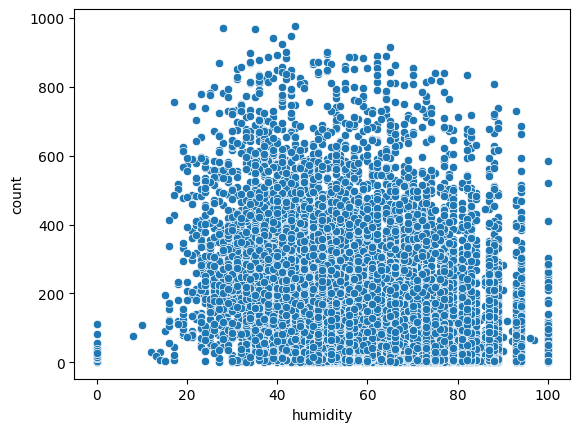

In [96]:
sns.scatterplot(x = "humidity", y = "count", data = df2)
plt.show()

In [97]:
stats , p_value = spearmanr(df2["humidity"],df2["count"])
print("Spearman Rank Correlation :",stats)
print("P-value :",p_value)

Spearman Rank Correlation : -0.35404912201756106
P-value : 0.0


In [158]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("There is a monotonic relationship between humidity and count")
else:
  print("Fail to reject the null hypothesis")
  print("There is no monotonic relationship between humidity and count")

Reject the null hypothesis
There is a monotonic relationship between humidity and count


Higher humidity discourages bike usage, leading to lower rental demand.

Comfort-related weather factors play a critical role in user behavior.

Demand forecasts and operations should account for humidity, especially on highly humid days.

4. Windspeed vs Couht

H0 : There is no monotonic relationship between Windspeed & count

H1 : There is monotonic relationship between Windspeed & count

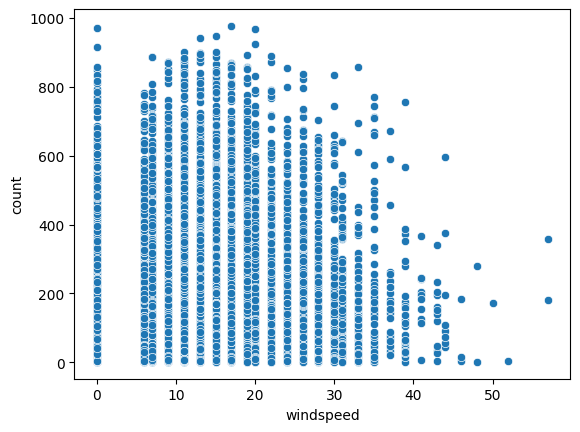

In [99]:
sns.scatterplot(x = "windspeed", y = "count", data = df2)
plt.show()

In [100]:
stats, p_value = spearmanr(df2["windspeed"],df2["count"])
print("Spearman Rank Correlation :",stats)
print("P-value :",p_value)

Spearman Rank Correlation : 0.1357773747113304
P-value : 5.9015220272171205e-46


In [159]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("There is a monotonic relationship between windspeed and count")
else:
  print("Fail to reject the null hypothesis")
  print("There is no monotonic relationship between windspeed and count")

Reject the null hypothesis
There is a monotonic relationship between windspeed and count


Windspeed has very little practical impact on rental demand.

Changes in windspeed do not meaningfully alter user behavior.

Windspeed can be included in models, but it should have low priority compared to temperature, humidity, or user type.

5. Casual vs Count

H0 : There is no monotonic relationship between Casual & count

H1 : There is monotonic relationship between Casual & count

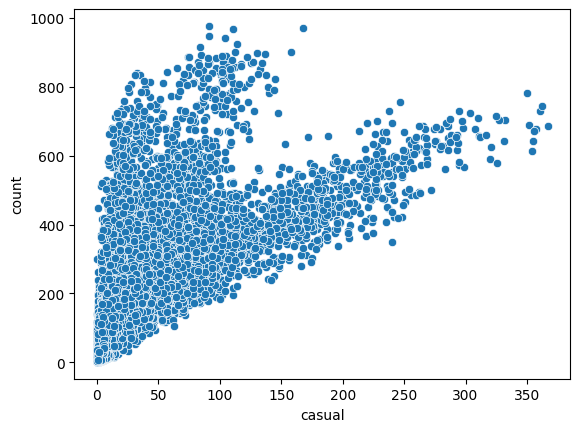

In [103]:
sns.scatterplot(x = "casual", y = "count", data = df2)
plt.show()

In [104]:
stats, p_value = spearmanr(df2["casual"],df2["count"])
print("Spearman Rank Correlation :",stats)
print("P-value :",p_value)

Spearman Rank Correlation : 0.8473776754290643
P-value : 0.0


In [160]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("There is a monotonic relationship between casual and count")
else:
  print("Fail to reject the null hypothesis")
  print("There is no monotonic relationship between casual and count")

Reject the null hypothesis
There is a monotonic relationship between casual and count


Casual users are a major driver of demand spikes, especially on favorable days.

Marketing and promotions targeting casual riders can significantly boost total rentals.

Casual demand should be closely monitored for capacity planning and peak-day operations.

6. Registered vs count

H0 : There is no linear relationship between Registered & count

H1 : There is linear relationship between Registered & count

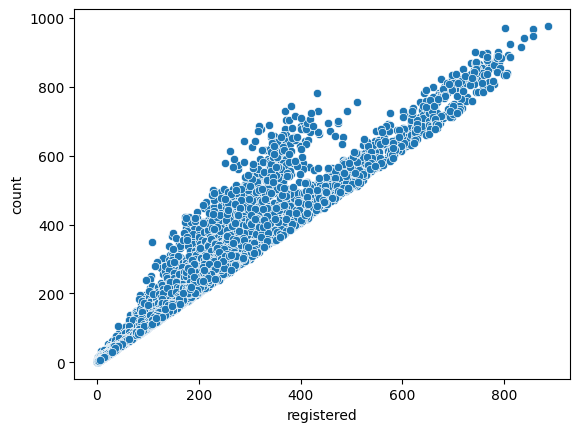

In [107]:
sns.scatterplot(x = "registered", y = "count", data = df2)
plt.show()

In [164]:
stats , p_value = pearsonr(df2["registered"],df2["count"])
print("Pearson Rank Correlation :",stats)
print("P-value :",p_value)

Pearson Rank Correlation : 0.970948105809828
P-value : 0.0


In [165]:
if p_value < 0.05:
  print("Reject the null hypothesis")
  print("There is a linear relationship between registered and count")
else:
  print("Fail to reject the null hypothesis")
  print("There is no linear relationship between registered and count")

Reject the null hypothesis
There is a linear relationship between registered and count


Registered users are the primary driver of overall demand, accounting for most rentals.

Demand forecasting accuracy will be highest when models prioritize registered-user behavior.

Retention strategies for registered users will have the largest impact on revenue and utilization.

Overall Interpretation :      

The analysis shows that Yulu’s rental demand is driven primarily by user behavior rather than calendar-based or categorical environmental factors. Registered users are the strongest and most stable predictor of total demand, exhibiting an almost perfect linear relationship with rentals, while casual users contribute significantly to demand variability and spikes. Weather comfort variables such as temperature and feels-like temperature have a moderate positive influence on demand, whereas humidity negatively affects usage. Windspeed has a statistically significant but practically negligible impact. Importantly, season and weather as categorical variables, as well as their interaction, do not significantly affect average rental demand, indicating that demand does not change meaningfully across seasons or weather labels. Overall, most variation in rentals is explained by user type and comfort-related conditions rather than seasonal patterns.

Overall Recommendation:  

Yulu should prioritize strategies that strengthen and retain registered users, as they form the core and most predictable demand base. Pricing and subscription models should remain stable for these users, while dynamic promotions can be targeted at casual users during favorable weather and non-working days to capitalize on demand spikes. Fleet allocation should not be driven by season alone but should instead respond to short-term weather comfort indicators such as temperature and humidity. Marketing efforts should differentiate between working days (commuter-focused messaging) and non-working days (leisure-oriented campaigns). For demand forecasting, models should emphasize registered-user trends and incorporate non-linear weather variables rather than relying heavily on season or categorical weather features.